# Injectivity (Monotonicity) Constraint Toggle — Comparison

Compares correction results across four modes:
1. **Jdet only** — gradient-based Jacobian determinant constraint
2. **Jdet + Shoelace** — also enforce positive geometric quad-cell areas
3. **Jdet + Injectivity** — also enforce monotonicity of deformed coordinates (sufficient for global injectivity on structured grids)
4. **Jdet + Shoelace + Injectivity** — all three constraints combined

**Monotonicity constraint:** For a structured grid with unit spacing, global injectivity is guaranteed when:
- `def_x[i, j+1] > def_x[i, j]` (x increases along rows)
- `def_y[i+1, j] > def_y[i, j]` (y increases along columns)

This is a sufficient (but not necessary) condition — more restrictive than Jacobian or shoelace alone, and may increase L2 error.

In [1]:
import numpy as np
import time

from modules.dvfopt import (
    iterative_parallel,
    jacobian_det2D,
    shoelace_det2D,
    _monotonicity_diffs_2d,
)
from modules.dvfviz import (
    plot_grid_before_after,
    plot_checkerboard_before_after,
    plot_neg_jdet_neighborhoods,
)
from modules.testcases import (
    SYNTHETIC_CASES, RANDOM_DVF_CASES,
    make_deformation, make_random_dvf,
)

## Helper: run all four modes and compare

In [2]:
JDET_THRESHOLD = 0.01
ERR_TOL = 1e-5

MODES = [
    ("jdet-only",         dict(enforce_shoelace=False, enforce_injectivity=False)),
    ("jdet+shoe",         dict(enforce_shoelace=True,  enforce_injectivity=False)),
    ("jdet+inject",       dict(enforce_shoelace=False, enforce_injectivity=True)),
    ("jdet+shoe+inject",  dict(enforce_shoelace=True,  enforce_injectivity=True)),
]


def summarize(label, deformation, phi):
    """Print Jacobian, shoelace, and monotonicity stats."""
    jac = jacobian_det2D(phi)
    shoe = shoelace_det2D(phi)
    h_mono, v_mono = _monotonicity_diffs_2d(phi[0], phi[1])
    phi_init = np.stack([deformation[-2, 0], deformation[-1, 0]])
    l2 = float(np.sqrt(np.sum((phi - phi_init) ** 2)))
    n_neg_jac = int((jac <= 0).sum())
    n_neg_shoe = int((shoe <= 0).sum())
    min_jac = float(jac.min())
    min_shoe = float(shoe.min())
    min_h = float(h_mono.min())
    min_v = float(v_mono.min())
    mono_ok = min_h >= JDET_THRESHOLD - ERR_TOL and min_v >= JDET_THRESHOLD - ERR_TOL
    print(f"  [{label:20s}]  neg_jdet={n_neg_jac}  min_jdet={min_jac:+.4f}"
          f"  neg_shoe={n_neg_shoe}  min_shoe={min_shoe:+.4f}"
          f"  min_h={min_h:+.4f}  min_v={min_v:+.4f}"
          f"  mono={'OK' if mono_ok else 'FAIL'}  L2={l2:.4f}")
    return dict(n_neg_jac=n_neg_jac, n_neg_shoe=n_neg_shoe,
                min_jac=min_jac, min_shoe=min_shoe,
                min_h=min_h, min_v=min_v, mono_ok=mono_ok, l2=l2)


def compare(key, deformation):
    """Run correction in all modes and visualise."""
    print(f"\n{'='*80}")
    print(f"  {key}  |  shape={deformation.shape[-2:]}")
    print(f"{'='*80}")

    # Initial stats
    phi_init = np.stack([deformation[-2, 0], deformation[-1, 0]])
    jac0 = jacobian_det2D(phi_init)
    shoe0 = shoelace_det2D(phi_init)
    h0, v0 = _monotonicity_diffs_2d(phi_init[0], phi_init[1])
    print(f"  [initial]  neg_jdet={int((jac0 <= 0).sum())}  min_jdet={float(jac0.min()):+.4f}"
          f"  neg_shoe={int((shoe0 <= 0).sum())}  min_shoe={float(shoe0.min()):+.4f}"
          f"  min_h={float(h0.min()):+.4f}  min_v={float(v0.min()):+.4f}")

    results = {}
    for label, kwargs in MODES:
        t0 = time.perf_counter()
        phi = iterative_parallel(
            deformation.copy(), verbose=1, threshold=JDET_THRESHOLD, **kwargs,
        )
        elapsed = time.perf_counter() - t0
        stats = summarize(label, deformation, phi)
        stats["time"] = elapsed
        print(f"  Time: {elapsed:.2f}s")
        results[label] = (phi, stats)

    # Visualisations — grid comparison for each mode
    for label, (phi, stats) in results.items():
        plot_grid_before_after(deformation, phi, title=f"{key} — {label}")

    return results

## Synthetic test cases

These are the cases where grid overlap was observed with Jdet-only and Jdet+Shoelace modes.


  01a_10x10_crossing  |  shape=(10, 10)
  [initial]  neg_jdet=9  min_jdet=-1.0246  neg_shoe=10  min_shoe=-0.7716  min_h=-1.4773  min_v=+0.9952
[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 9  |  min Jdet: -1.024567
[iter    1]  serial  fix (  3,  5)  neg_pixels=9
         -> neg_jdet     0  min_jdet +0.010000  L2 2.2706  win 9  sub-iters 1
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP — hybrid parallel)
------------------------------------------------------------
  Grid size        : 10 x 10
  Iterations       : 1  (serial=1, parallel=0)
  Neg-Jdet      9 ->     0
  Min Jdet  -1.024567 -> +0.010000
  L2 error         : 2.270564
  Time             : 0.14s
  [jdet-only           ]  neg_jdet=0  min_jdet=+0.0100  neg_shoe=4  min_shoe=-0.9718  min_h=-1.9560  min_v=-0.0183  mono=FAIL  L2=2.2706
  Time: 0.14s
[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixel

c:\Users\Andy\Documents\GitHub\UCI-iGravi\deformation-field-processing\modules\dvfviz.py:842: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.87, 1])


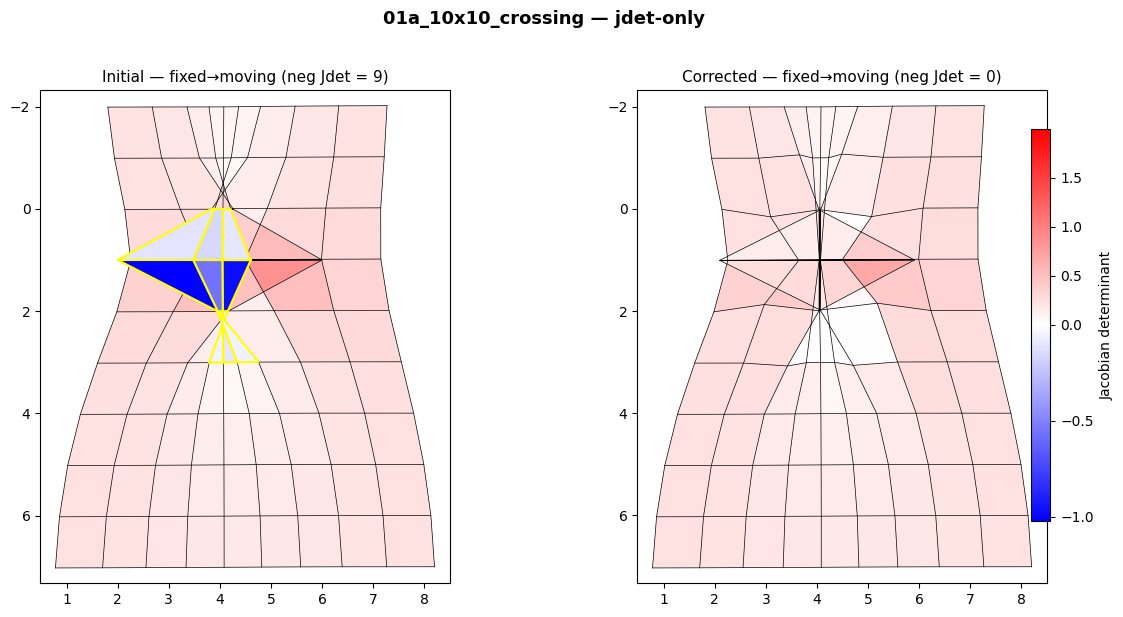

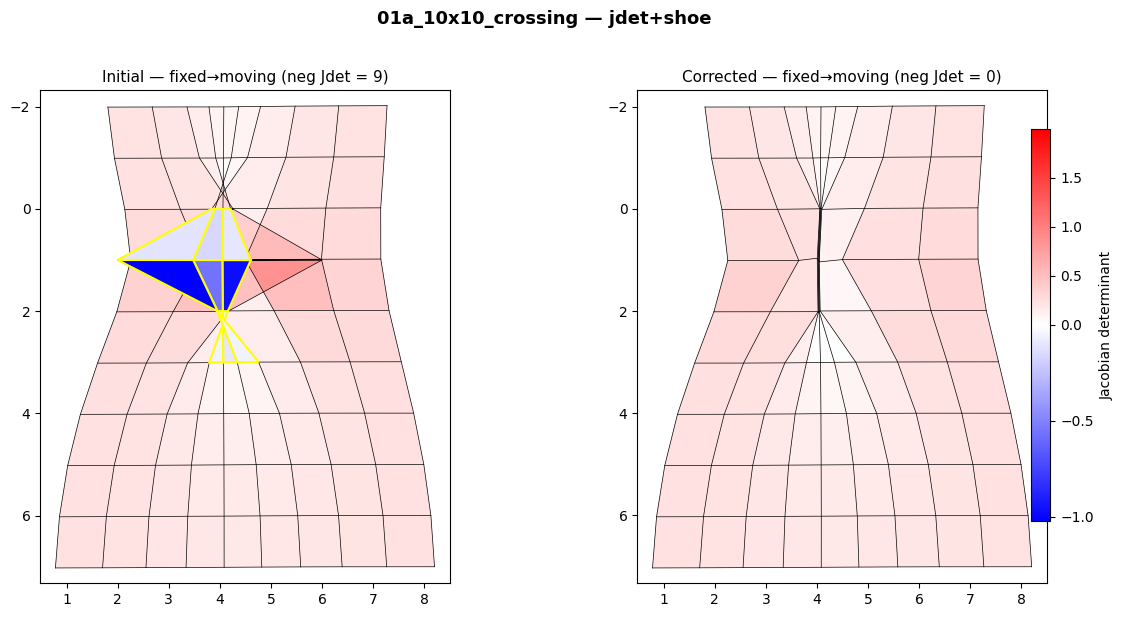

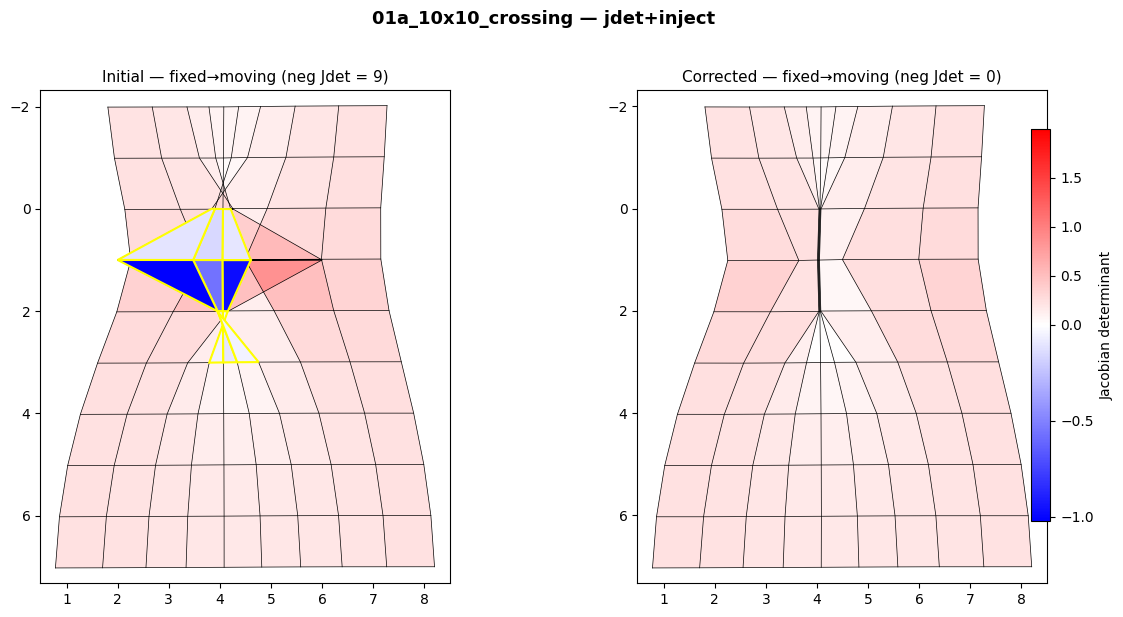

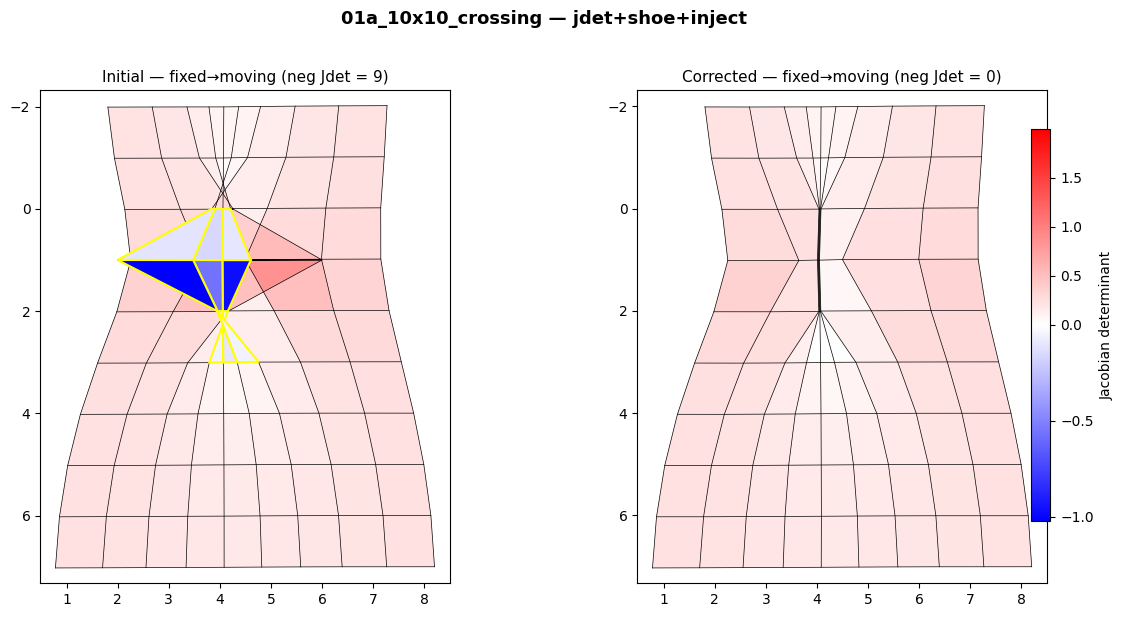


  01b_10x10_opposite  |  shape=(10, 10)
  [initial]  neg_jdet=6  min_jdet=-1.1540  neg_shoe=7  min_shoe=-0.5943  min_h=-1.1540  min_v=+1.0000
[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 6  |  min Jdet: -1.154032
[iter    1]  serial  fix (  2,  1)  neg_pixels=4
         -> neg_jdet     0  min_jdet +0.010000  L2 1.4622  win 9  sub-iters 1
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP — hybrid parallel)
------------------------------------------------------------
  Grid size        : 10 x 10
  Iterations       : 1  (serial=1, parallel=0)
  Neg-Jdet      6 ->     0
  Min Jdet  -1.154032 -> +0.010000
  L2 error         : 1.462154
  Time             : 0.17s
  [jdet-only           ]  neg_jdet=0  min_jdet=+0.0100  neg_shoe=3  min_shoe=-0.0987  min_h=-0.3824  min_v=+0.6257  mono=FAIL  L2=1.4622
  Time: 0.17s
[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels

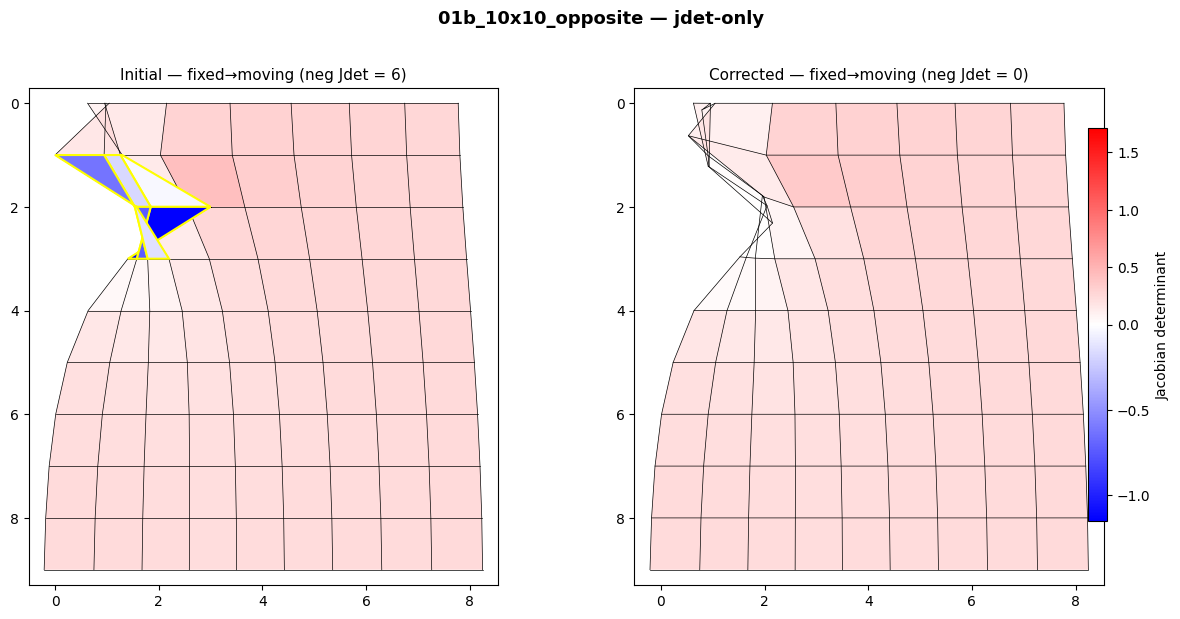

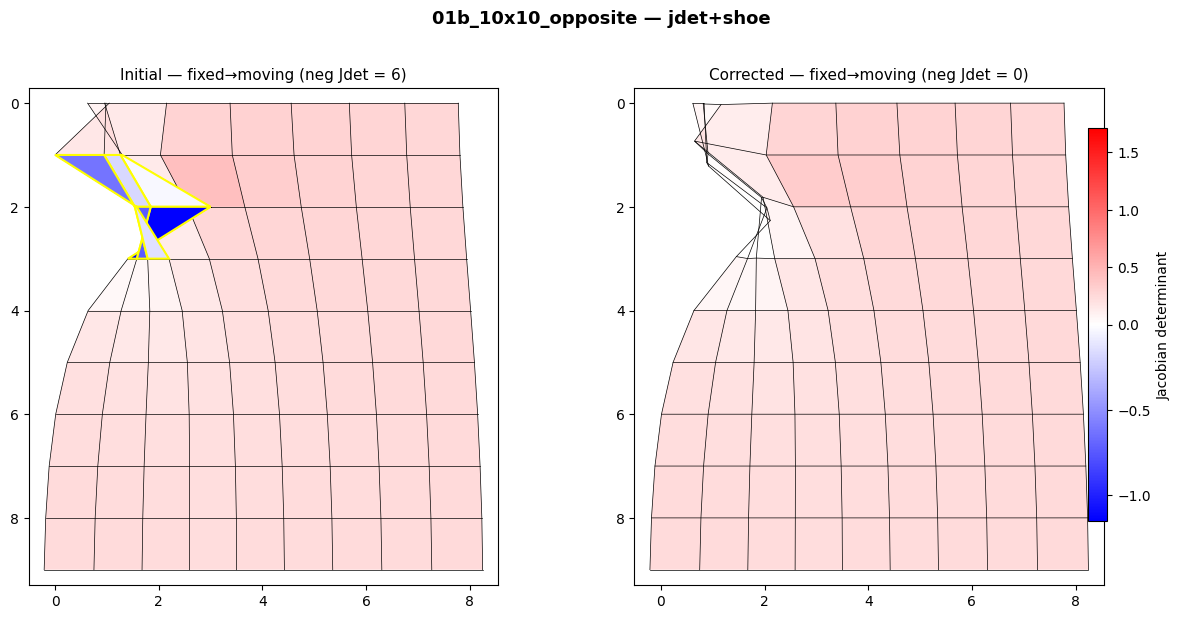

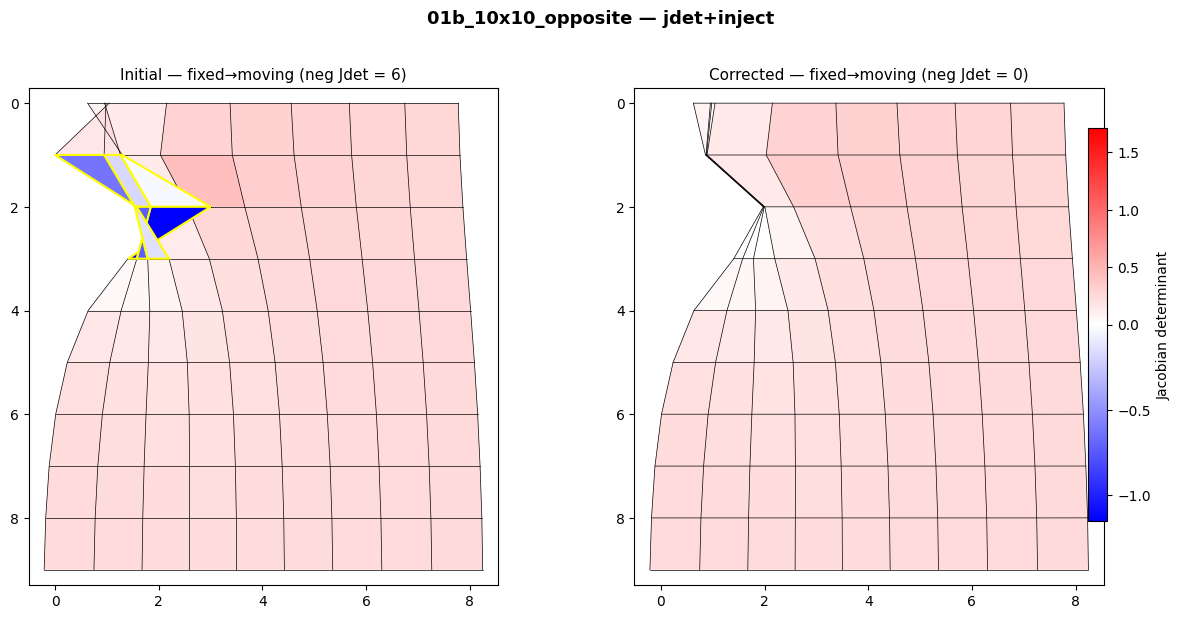

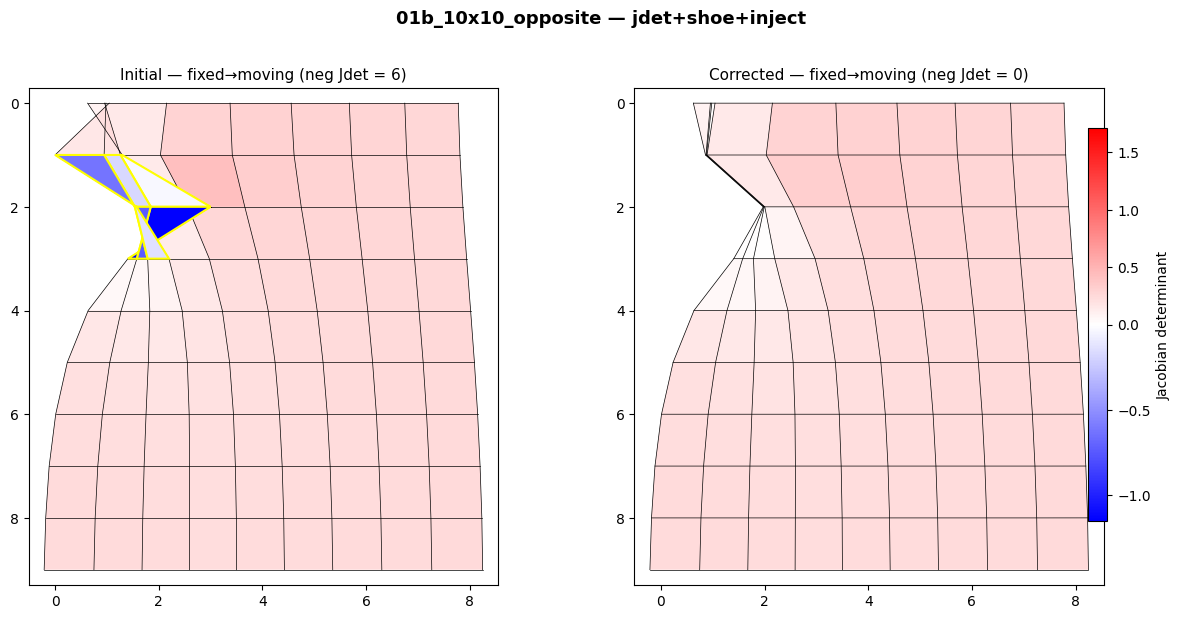

In [3]:
for case_key in ["01a_10x10_crossing", "01b_10x10_opposite"]:
    deformation, msample, fsample = make_deformation(case_key)
    results = compare(case_key, deformation)

## Random DVF test cases

In [ ]:
for case_key in ["03a_10x10_random_seed_42"]:
    deformation = make_random_dvf(case_key)
    results = compare(case_key, deformation)


  03a_10x10_random_seed_42  |  shape=(10, 10)
  [initial]  neg_jdet=43  min_jdet=-34.2105  neg_shoe=39  min_shoe=-28.0464  min_h=-5.7768  min_v=-5.1010
[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 43  |  min Jdet: -34.210474
[iter    1]  serial  fix (  3,  1)  neg_pixels=24
         -> neg_jdet    17  min_jdet -52.373797  L2 18.4694  win 9  sub-iters 1
[iter    2]  serial  fix (  1,  8)  neg_pixels=6
         -> neg_jdet    18  min_jdet -20.538568  L2 17.9678  win 9  sub-iters 1
[iter    3]  serial  fix (  2,  1)  neg_pixels=9
         -> neg_jdet    16  min_jdet -41.928442  L2 18.6892  win 9  sub-iters 1
[iter    4]  serial  fix (  8,  1)  neg_pixels=6
         -> neg_jdet    14  min_jdet -41.928442  L2 17.4897  win 9  sub-iters 1
[iter    5]  serial  fix (  1,  2)  neg_pixels=5
         -> neg_jdet    15  min_jdet -41.919193  L2 18.8139  win 9  sub-iters 1
[iter    6]  serial  fix (  8,  1)  neg_pixels=6
         -> ne

## Summary table

Collect results for all cases side-by-side.

In [ ]:
import pandas as pd

rows = []
for case_key in ["01a_10x10_crossing", "01b_10x10_opposite", "03a_10x10_random_seed_42"]:
    if case_key.startswith("03"):
        deformation = make_random_dvf(case_key)
    else:
        deformation, _, _ = make_deformation(case_key)

    for label, kwargs in MODES:
        phi = iterative_parallel(
            deformation.copy(), verbose=0, threshold=JDET_THRESHOLD, **kwargs,
        )
        jac = jacobian_det2D(phi)
        shoe = shoelace_det2D(phi)
        h, v = _monotonicity_diffs_2d(phi[0], phi[1])
        phi_init = np.stack([deformation[-2, 0], deformation[-1, 0]])
        l2 = float(np.sqrt(np.sum((phi - phi_init) ** 2)))
        rows.append(dict(
            case=case_key, mode=label,
            neg_jdet=int((jac <= 0).sum()),
            min_jdet=float(jac.min()),
            neg_shoe=int((shoe <= 0).sum()),
            min_shoe=float(shoe.min()),
            min_h_mono=float(h.min()),
            min_v_mono=float(v.min()),
            L2=l2,
        ))

df = pd.DataFrame(rows)
df.style.format({
    "min_jdet": "{:+.4f}", "min_shoe": "{:+.4f}",
    "min_h_mono": "{:+.4f}", "min_v_mono": "{:+.4f}", "L2": "{:.4f}",
})